In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

df = pd.read_csv("creditcard_2023.csv")

print("File loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

File loaded successfully!
Shape: (568630, 31)
Columns: ['id', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [67]:
print("First 5 Rows")
df.head()

First 5 Rows


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

In [71]:
df.describe().round(2)

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,...,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.00,568630.0
mean,284314.50,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,...,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,12041.96,0.5
std,164149.49,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,6919.64,0.5
min,0.00,-3.50,-49.97,-3.18,-4.95,-9.95,-21.11,-4.35,-10.76,-3.75,...,-19.38,-7.73,-30.30,-4.07,-13.61,-8.23,-10.50,-39.04,50.01,0.0
25%,142157.25,-0.57,-0.49,-0.65,-0.66,-0.29,-0.45,-0.28,-0.19,-0.57,...,-0.17,-0.49,-0.24,-0.65,-0.55,-0.63,-0.30,-0.23,6054.89,0.0
50%,284314.50,-0.09,-0.14,0.00,-0.07,0.08,0.08,0.23,-0.11,0.09,...,-0.04,-0.03,-0.06,0.02,-0.01,-0.01,-0.17,-0.01,12030.15,0.5
75%,426471.75,0.83,0.34,0.63,0.71,0.44,0.50,0.53,0.05,0.56,...,0.15,0.46,0.16,0.70,0.55,0.67,0.33,0.41,18036.33,1.0
max,568629.00,2.23,4.36,14.13,3.20,42.72,26.17,217.87,5.96,20.27,...,8.09,12.63,31.71,12.97,14.62,5.62,113.23,77.26,24039.93,1.0


In [72]:
print("===== Missing Values =====")
print(df.isnull().sum())

===== Missing Values =====
id        0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [75]:
print("===== Duplicates =====")
print("Total Duplicates:", df.duplicated().sum())

===== Duplicates =====
Total Duplicates: 0


In [76]:
print("===== Last 5 Rows =====")
print(df.tail())

===== Last 5 Rows =====
            id        V1        V2        V3        V4        V5        V6  \
568625  568625 -0.833437  0.061886 -0.899794  0.904227 -1.002401  0.481454   
568626  568626 -0.670459 -0.202896 -0.068129 -0.267328 -0.133660  0.237148   
568627  568627 -0.311997 -0.004095  0.137526 -0.035893 -0.042291  0.121098   
568628  568628  0.636871 -0.516970 -0.300889 -0.144480  0.131042 -0.294148   
568629  568629 -0.795144  0.433236 -0.649140  0.374732 -0.244976 -0.603493   

              V7        V8        V9  ...       V21       V22       V23  \
568625 -0.370393  0.189694 -0.938153  ...  0.167503  0.419731  1.288249   
568626 -0.016935 -0.147733  0.483894  ...  0.031874  0.388161 -0.154257   
568627 -0.070958 -0.019997 -0.122048  ...  0.140788  0.536523 -0.211100   
568628  0.580568 -0.207723  0.893527  ... -0.060381 -0.195609 -0.175488   
568629 -0.347613 -0.340814  0.253971  ...  0.534853 -0.291514  0.157303   

             V24       V25       V26       V27       V28

In [77]:
print(df['Class'].value_counts())

Class
0    284315
1    284315
Name: count, dtype: int64


In [78]:
print(df.isnull().sum())

id        0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [79]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [81]:
print(df.dtypes)

id          int64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [85]:
print(df['Class'].value_counts())
print("\nFraud %:", round(df['Class'].mean() * 100, 2), "%")

Class
0    284315
1    284315
Name: count, dtype: int64

Fraud %: 50.0 %


In [86]:
print(df.groupby('Class')['Amount'].describe().round(2))

          count      mean      std    min      25%       50%       75%  \
Class                                                                    
0      284315.0  12026.31  6929.50  50.12  6034.54  11996.90  18040.26   
1      284315.0  12057.60  6909.75  50.01  6074.64  12062.45  18033.78   

            max  
Class            
0      24039.93  
1      24039.93  


In [87]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print("Fraud Mean:\n", fraud[['V1','V2','V3','V4','V5']].mean().round(2))
print("\nNormal Mean:\n", normal[['V1','V2','V3','V4','V5']].mean().round(2))

Fraud Mean:
 V1   -0.51
V2    0.49
V3   -0.68
V4    0.74
V5   -0.34
dtype: float64

Normal Mean:
 V1    0.51
V2   -0.49
V3    0.68
V4   -0.74
V5    0.34
dtype: float64


In [88]:
print(df[['V1','V2','V3','V4','V5','Amount','Class']].corr()['Class'].round(2))

V1       -0.51
V2        0.49
V3       -0.68
V4        0.74
V5       -0.34
Amount    0.00
Class     1.00
Name: Class, dtype: float64


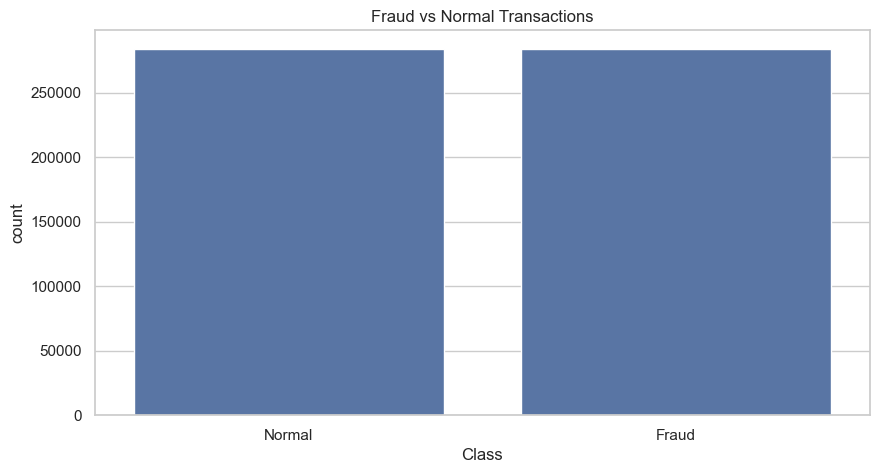

In [89]:
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Normal Transactions')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.show()

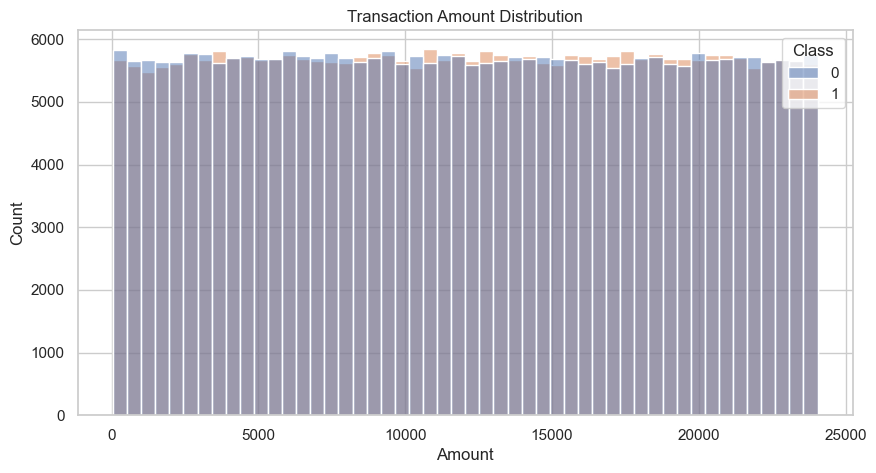

In [93]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Amount', hue='Class', bins=50)
plt.title('Transaction Amount Distribution')
plt.show()

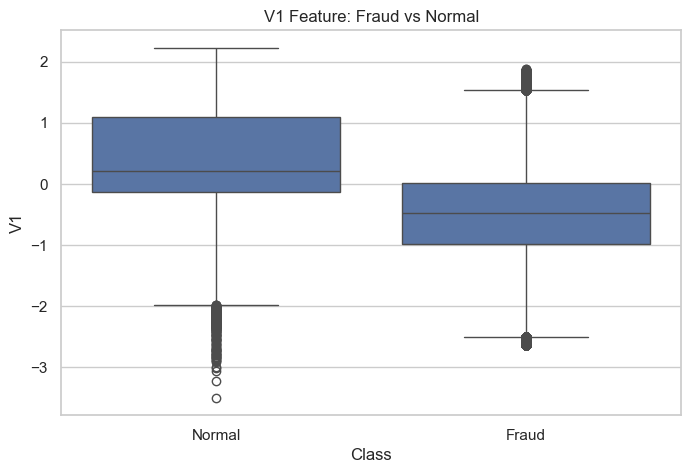

In [97]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='V1', data=df)
plt.title('V1 Feature: Fraud vs Normal')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.show()

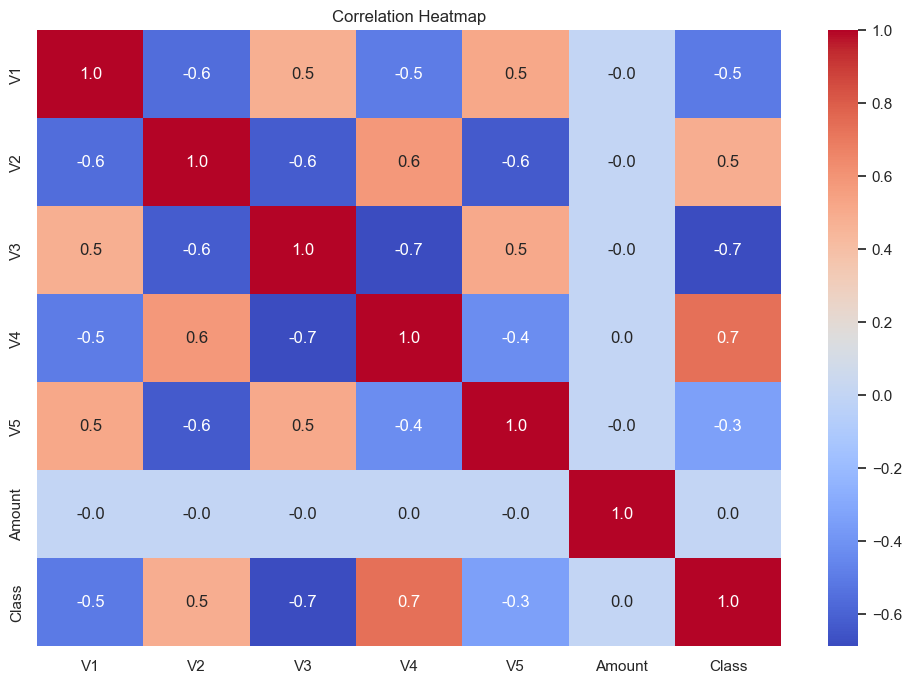

In [98]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[['V1','V2','V3','V4','V5','Amount','Class']].corr(), 
            annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [99]:
print(df['Class'].value_counts())

Class
0    284315
1    284315
Name: count, dtype: int64


In [101]:
X = df.drop(['id', 'Class'], axis=1)
y = df['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (568630, 29)
y shape: (568630,)


In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (454904, 29)
Test size: (113726, 29)


In [103]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


In [104]:
y_pred = model.predict(X_test)

print("First 10 Predictions:", y_pred[:10])
print("Actual Values:       ", y_test.values[:10])

First 10 Predictions: [1 1 0 1 1 0 1 1 0 1]
Actual Values:        [1 1 0 1 1 0 1 1 0 1]


In [106]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 96.48 %


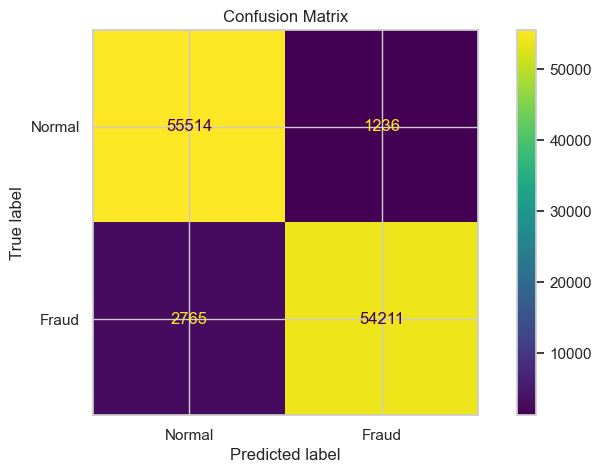

In [107]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal','Fraud']).plot()
plt.title('Confusion Matrix')
plt.show()

In [108]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, 
      target_names=['Normal', 'Fraud']))

              precision    recall  f1-score   support

      Normal       0.95      0.98      0.97     56750
       Fraud       0.98      0.95      0.96     56976

    accuracy                           0.96    113726
   macro avg       0.97      0.96      0.96    113726
weighted avg       0.97      0.96      0.96    113726



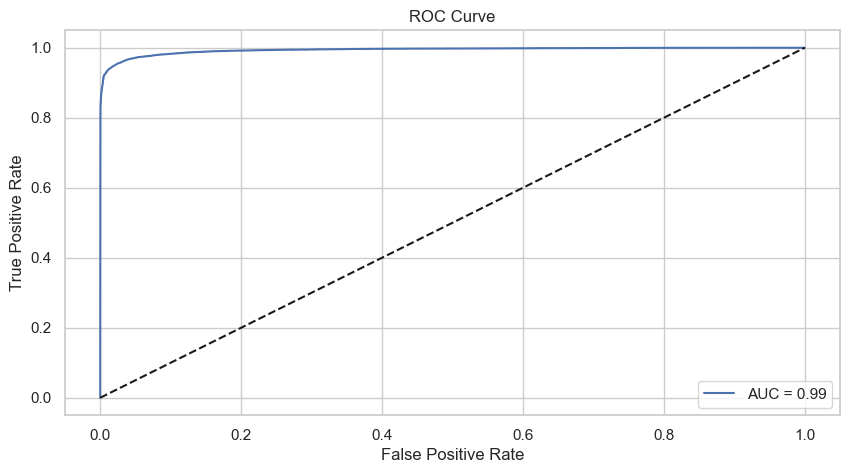

In [109]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

plt.plot(fpr, tpr, label=f'AUC = {round(auc, 2)}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [112]:
save_path = r"C:\Users\HP\Desktop/Credit Card Fraud Detection/Fraud_Detection_Cleaned.csv"
df.to_csv(save_path, index=False)
print("File saved successfully!")
print(f"Location : {save_path}")
print(f"Rows     : {df.shape[0]:,}")
print(f"Columns  : {df.shape[1]}")

File saved successfully!
Location : C:\Users\HP\Desktop/Credit Card Fraud Detection/Fraud_Detection_Cleaned.csv
Rows     : 568,630
Columns  : 31
